# Tech Challenge — Fase 4
## Etapa 1: Coleta e Pré-processamento dos Dados

Este notebook cobre o **ponto 1** do desafio: coletar preços históricos de ações
via `yfinance` e preparar os dados para alimentar uma rede neural **LSTM**.

Todo o pré-processamento vive aqui. A Etapa 2 recebe os arrays prontos e só
constrói, treina e avalia o modelo — não refaz transformação alguma.

Fluxo:
1. Coleta dos dados (Yahoo Finance)
2. Inspeção e limpeza
3. Análise exploratória rápida
4. Seleção da feature alvo (`Close`)
5. Alvo do modelo: log-retorno
6. Split treino/validação respeitando a ordem temporal
7. Escalonamento (`StandardScaler` ajustado só no treino)
8. Criação das janelas temporais (sequências) para a LSTM
9. Salvamento dos artefatos (arrays + scaler + metadados)


## 0. Instalação e imports

Caso esteja rodando localmente ou no Colab, descomente a linha de instalação.

In [1]:
# !pip install yfinance scikit-learn pandas numpy matplotlib joblib

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib
import time
import yfinance as yf

# Reprodutibilidade
np.random.seed(42)

# Pasta para salvar os artefatos da etapa
ARTIFACTS_DIR = "artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print("Setup OK")

mkdir -p failed for path /.cache/matplotlib: [Errno 13] Permission denied: '/.cache'
Matplotlib created a temporary cache directory at /tmp/matplotlib-i6u13pjb because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup OK


## 1. Coleta dos Dados

Defina o símbolo da empresa e o intervalo de datas. Aqui usamos a **Apple (AAPL)**
como exemplo — troque por qualquer ticker (ex: `DIS`, `MSFT`, `PETR4.SA` para a B3).

In [2]:
SYMBOL = "AAPL"
START_DATE = "2018-01-01"
END_DATE = "2026-06-20"

def baixar_dados(symbol, start, end, tentativas=3):
    for i in range(tentativas):
        df = yf.Ticker(symbol).history(start=start, end=end, auto_adjust=True)
        if not df.empty:
            return df
        print(f"Tentativa {i+1} vazia, aguardando...")
        time.sleep(2)
    raise ValueError(f"Sem dados para {symbol} após {tentativas} tentativas.")

df = baixar_dados(SYMBOL, START_DATE, END_DATE)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

if df.empty:
    raise ValueError(
        f"Nenhum dado foi retornado para {SYMBOL} entre {START_DATE} e {END_DATE}. "
        "Verifique o ticker, ajuste o intervalo de datas ou tente novamente mais tarde."
    )

print(f"Linhas baixadas: {len(df)}")
df.head()

Linhas baixadas: 2127


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2018-01-02 00:00:00-05:00,39.776175,40.276415,39.565791,40.267063,102223600,0.0,0.0
2018-01-03 00:00:00-05:00,40.330195,40.802386,40.196955,40.260067,118071600,0.0,0.0
2018-01-04 00:00:00-05:00,40.332513,40.549910,40.224987,40.447056,89738400,0.0,0.0
2018-01-05 00:00:00-05:00,40.542920,40.994071,40.451755,40.907581,94640000,0.0,0.0
2018-01-08 00:00:00-05:00,40.755630,41.050164,40.657449,40.755630,82271200,0.0,0.0


## 2. Inspeção e Limpeza

Verificamos tipos, valores ausentes e a continuidade temporal.

In [3]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2127 entries, 2018-01-02 00:00:00-05:00 to 2026-06-18 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2127 non-null   float64
 1   High          2127 non-null   float64
 2   Low           2127 non-null   float64
 3   Close         2127 non-null   float64
 4   Volume        2127 non-null   int64  
 5   Dividends     2127 non-null   float64
 6   Stock Splits  2127 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 132.9 KB


In [4]:
# Valores ausentes por coluna
print("Valores ausentes:")
print(df.isna().sum())

# Datas duplicadas?
print("\nDatas duplicadas:", df.index.duplicated().sum())

Valores ausentes:
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

Datas duplicadas: 0


In [5]:
# Pregões não têm fins de semana/feriados, então gaps de calendário são esperados.
# Tratamos apenas NaNs internos (ex: dados faltantes pontuais) com forward fill.
df = df.sort_index()
df = df.ffill().dropna()

print("Após limpeza:", df.shape)
print("Período:", df.index.min().date(), "->", df.index.max().date())

Após limpeza: (2127, 7)
Período: 2018-01-02 -> 2026-06-18


## 3. Análise Exploratória Rápida

Visualizamos a série do preço de fechamento — é o que vamos prever.

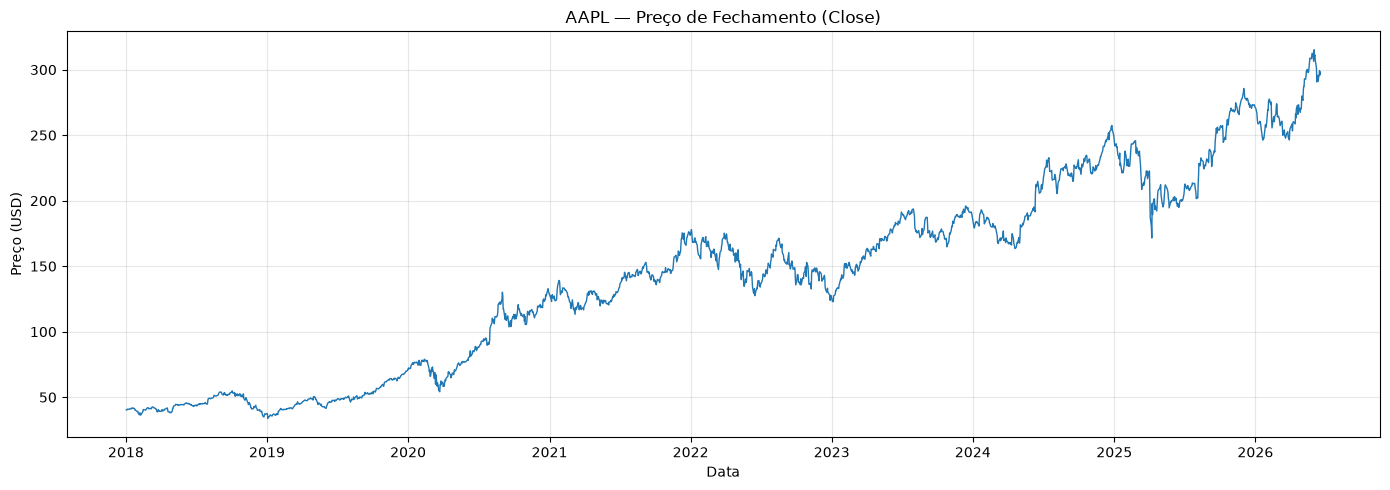

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"], linewidth=1)
plt.title(f"{SYMBOL} — Preço de Fechamento (Close)")
plt.xlabel("Data")
plt.ylabel("Preço (USD)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# Estatísticas descritivas do alvo
df["Close"].describe()

count    2127.000000
mean      142.729557
std        72.052981
min        33.737011
25%        68.428780
50%       145.638199
75%       191.271698
max       315.200012
Name: Close, dtype: float64

## 4. Seleção da Feature Alvo

Para um primeiro modelo LSTM univariado, usamos apenas o **Close**.
As demais colunas seguem no CSV limpo, disponíveis para uma versão
multivariada no futuro.

In [8]:
close_prices = df[["Close"]].copy()
print("Shape da série alvo:", close_prices.shape)
close_prices.tail()

Shape da série alvo: (2127, 1)


,Close
Date,
2026-06-12 00:00:00-04:00,291.130005
2026-06-15 00:00:00-04:00,296.420013
2026-06-16 00:00:00-04:00,299.239990
2026-06-17 00:00:00-04:00,295.950012
2026-06-18 00:00:00-04:00,298.010010


## 5. Alvo do Modelo: Log-retorno

O preço bruto é não-estacionário: a média sobe ao longo dos anos e o modelo
treinado em uma faixa de valores não generaliza para outra. O **log-retorno**
resolve isso:

```text
r_t = ln(P_t / P_{t-1}) = ln(P_t) - ln(P_{t-1})
```

A série resultante é aproximadamente estacionária e centrada em zero. Na hora
de servir, o preço é reconstruído com `P̂_t = P_{t-1} · exp(r̂_t)` — é essa a
fórmula que a API aplica.

Note que `n` preços geram `n-1` retornos: o primeiro dia não tem anterior.

In [9]:
prices = close_prices["Close"].astype(float).values
dates  = close_prices.index

if np.any(prices <= 0):
    raise ValueError("Há preços não positivos; o log-retorno exige preços > 0.")

log_prices = np.log(prices)
returns = np.diff(log_prices)          # returns[i] = logP[i+1] - logP[i]

print(f"Preços: {len(prices)} | Log-retornos: {len(returns)}")
print(f"Média:  {returns.mean():+.6f} | Desvio: {returns.std():.6f}")
print(f"Mín/Máx: {returns.min():+.6f} / {returns.max():+.6f}")

Preços: 2127 | Log-retornos: 2126
Média:  +0.000941 | Desvio: 0.019170
Mín/Máx: -0.137708 / +0.142617


## 6. Split Treino / Validação (temporal)

**Importante:** em séries temporais **não** se embaralha os dados. O conjunto de
validação deve vir *depois* do de treino no tempo. Usamos 80% / 20%.

O corte é definido sobre a série de **preços** e traduzido para a série de
retornos, que tem um elemento a menos: `split_ret_idx = split_price_idx - 1`.

In [10]:
TRAIN_RATIO = 0.80
split_price_idx = int(len(prices) * TRAIN_RATIO)
split_ret_idx   = split_price_idx - 1     # fronteira treino/val na série de retornos

if split_price_idx <= 0 or split_price_idx >= len(prices):
    raise ValueError(
        "O split temporal gerou treino ou validação vazios. "
        "Revise a quantidade de dados disponível ou ajuste TRAIN_RATIO."
    )

print(f"Treino:    {split_price_idx} preços "
      f"({dates[0].date()} -> {dates[split_price_idx - 1].date()})")
print(f"Validação: {len(prices) - split_price_idx} preços "
      f"({dates[split_price_idx].date()} -> {dates[-1].date()})")

Treino:    1701 preços (2018-01-02 -> 2024-10-04)
Validação: 426 preços (2024-10-07 -> 2026-06-18)


## 7. Escalonamento (StandardScaler)

O log-retorno já é centrado perto de zero, mas a escala é pequena (desvio na
casa de 0,02). O `StandardScaler` deixa a série com média 0 e desvio 1, o que
ajuda a convergência da LSTM.

**Cuidado com data leakage:** o scaler é ajustado (`fit`) **apenas nos retornos
de treino** e depois apenas aplicado (`transform`) na série inteira. Ajustar no
conjunto completo vazaria estatísticas do futuro para dentro do treino.

Este `ret_scaler` é artefato de produção: a API precisa dele para escalonar a
entrada e reverter o retorno previsto antes de reconstruir o preço.

In [11]:
ret_scaler = StandardScaler()
ret_scaler.fit(returns[:split_ret_idx].reshape(-1, 1))     # fit só no treino
returns_scaled = ret_scaler.transform(returns.reshape(-1, 1)).flatten()

treino_esc = returns_scaled[:split_ret_idx]
valid_esc  = returns_scaled[split_ret_idx:]

print(f"Ajustado em {split_ret_idx} retornos de treino")
print(f"mean_={ret_scaler.mean_[0]:+.6f} | scale_={ret_scaler.scale_[0]:.6f}")
print(f"Treino escalonado -> média {treino_esc.mean():+.4f} | desvio {treino_esc.std():.4f}")
print(f"Valid. escalonado -> média {valid_esc.mean():+.4f} | desvio {valid_esc.std():.4f}")

Ajustado em 1700 retornos de treino
mean_=+0.001012 | scale_=0.019473
Treino escalonado -> média +0.0000 | desvio 1.0000
Valid. escalonado -> média -0.0182 | desvio 0.9195


## 8. Criação das Janelas Temporais

A LSTM aprende a partir de **sequências**. Para prever o retorno do dia `k`,
usamos os `WINDOW_SIZE` retornos anteriores.

- `X`: blocos de `WINDOW_SIZE` retornos escalonados -> shape `(amostras, janela, 1)`
- `y`: o retorno escalonado do dia seguinte a cada bloco

Junto de cada janela de validação guardamos dois preços que a Etapa 2 precisa
para avaliar em escala real, e que não dá para recuperar a partir de `X` e `y`:

- `base_valid` = `P_{k-1}`, o preço sobre o qual a previsão é reconstruída
- `true_valid` = `P_k`, o preço realizado

A validação começa em `split_price_idx`, então suas primeiras janelas usam
retornos do fim do treino como contexto — sem isso os primeiros dias de
validação ficariam sem histórico.

In [12]:
WINDOW_SIZE = 60  # nº de retornos usados para prever o próximo

def make_windows(k_start, k_end):
    X, y, base_price, true_price = [], [], [], []
    for k in range(k_start, k_end):
        if k - 1 - WINDOW_SIZE < 0:
            continue
        X.append(returns_scaled[k - 1 - WINDOW_SIZE : k - 1])
        y.append(returns_scaled[k - 1])
        base_price.append(prices[k - 1])
        true_price.append(prices[k])
    # LSTM espera entrada 3D: (amostras, timesteps, features)
    X = np.array(X).reshape(-1, WINDOW_SIZE, 1)
    return X, np.array(y), np.array(base_price), np.array(true_price)

X_train, y_train, _, _                   = make_windows(WINDOW_SIZE + 1, split_price_idx)
X_valid, y_valid, base_valid, true_valid = make_windows(split_price_idx, len(prices))
valid_dates = dates[-len(true_valid):]

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "| y_valid:", y_valid.shape)
print("base_valid:", base_valid.shape, "| true_valid:", true_valid.shape)
print("Validação:", valid_dates[0].date(), "->", valid_dates[-1].date())

X_train: (1640, 60, 1) | y_train: (1640,)
X_valid: (426, 60, 1) | y_valid: (426,)
base_valid: (426,) | true_valid: (426,)
Validação: 2024-10-07 -> 2026-06-18


## 9. Salvamento dos Artefatos

Guardamos os arrays prontos, o **scaler** e os metadados. A Etapa 2 carrega
tudo isso e não repete nenhuma transformação.

O `ret_scaler.pkl` também é artefato de produção — a API o carrega junto do
modelo para escalonar a entrada e reverter a previsão para a escala de preço.

Os `.npy` e o `meta.pkl` não são versionados no git (veja o `.gitignore`):
são intermediários de treino, regerados ao executar este notebook.

In [13]:
np.save(os.path.join(ARTIFACTS_DIR, "X_train.npy"), X_train)
np.save(os.path.join(ARTIFACTS_DIR, "y_train.npy"), y_train)
np.save(os.path.join(ARTIFACTS_DIR, "X_valid.npy"), X_valid)
np.save(os.path.join(ARTIFACTS_DIR, "y_valid.npy"), y_valid)

# Preços da validação: a Etapa 2 reconstrói P_hat = base * exp(retorno) e
# compara com true_valid. Não dá para derivar isso de X_valid/y_valid.
np.save(os.path.join(ARTIFACTS_DIR, "base_valid.npy"), base_valid)
np.save(os.path.join(ARTIFACTS_DIR, "true_valid.npy"), true_valid)
np.save(os.path.join(ARTIFACTS_DIR, "valid_dates.npy"),
        valid_dates.tz_localize(None).values)

# Scaler dos log-retornos: usado na Etapa 2 e pela API
joblib.dump(ret_scaler, os.path.join(ARTIFACTS_DIR, "ret_scaler.pkl"))

# Salva também o dataframe limpo para referência/reuso
df.to_csv(os.path.join(ARTIFACTS_DIR, f"{SYMBOL}_clean.csv"))

# Metadados úteis para as próximas etapas
meta = {
    "symbol": SYMBOL,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "window_size": WINDOW_SIZE,
    "train_ratio": TRAIN_RATIO,
    "feature": "Close",
    "target": "log_return",
    "reconstruction": "P_hat = P_prev * exp(pred_return)",
}
joblib.dump(meta, os.path.join(ARTIFACTS_DIR, "meta.pkl"))

print("Artefatos salvos em:", os.path.abspath(ARTIFACTS_DIR))
for f in sorted(os.listdir(ARTIFACTS_DIR)):
    print(" -", f)

Artefatos salvos em: /home/doglas/Documents/FIAP/fiap-tech-challenge-4/notebooks/artifacts
 - AAPL_clean.csv
 - X_train.npy
 - X_valid.npy
 - base_valid.npy
 - meta.pkl
 - ret_scaler.pkl
 - true_valid.npy
 - valid_dates.npy
 - y_train.npy
 - y_valid.npy


## Pronto ✅

A Etapa 1 está completa e é a **única** etapa que transforma dados. O contrato
entregue à Etapa 2:

| Artefato | Conteúdo |
|---|---|
| `X_train.npy` / `y_train.npy` | janelas de treino e o retorno escalonado alvo |
| `X_valid.npy` / `y_valid.npy` | idem para a validação |
| `base_valid.npy` / `true_valid.npy` | `P_{k-1}` e `P_k` de cada janela de validação |
| `valid_dates.npy` | datas da validação, para os gráficos |
| `ret_scaler.pkl` | `StandardScaler` dos log-retornos (também usado pela API) |
| `meta.pkl` | símbolo, janela, `train_ratio`, alvo e fórmula de reconstrução |
| `AAPL_clean.csv` | série limpa, para referência e teste de carga |

A Etapa 2 carrega esses arquivos e passa direto para a arquitetura — não
recalcula retorno, não reajusta scaler e não refaz janelas.

**Próximos passos:**
- Etapa 2: montar a arquitetura LSTM no Keras/TensorFlow, treinar e avaliar (MAE, RMSE, MAPE)
- Etapa 3: salvar o modelo treinado (`.keras`)
- Etapa 4: servir via FastAPI/Flask
